In [1]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [4]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze() # df a series
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [5]:
# Logistic Regression
lr = LogisticRegression(class_weight="balanced", max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [6]:
# metricas
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Accuracy: 0.711
Precision: 0.3881578947368421
Recall: 0.7230392156862745
F1 Score: 0.5051369863013698
ROC-AUC: 0.7797720218740763


In [ ]:
# matriz de confusion
# TP TN
# FP FN
print(confusion_matrix(y_test, y_pred_lr))

[[1127  465]
 [ 113  295]]


In [8]:
# classification report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1592
           1       0.39      0.72      0.51       408

    accuracy                           0.71      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.80      0.71      0.74      2000



In [9]:
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import xgboost as xgb

c:\Users\albaro\Documents\!PROYECTOS-GIT\Proyecto-Master-DataScience-Evolve-AlvaroMartinez\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



===== Logistic Regression =====
Accuracy:  0.815
Precision: 0.653
Recall:    0.199
F1-Score:  0.305

===== Decision Tree =====
Accuracy:  0.780
Precision: 0.466
Recall:    0.532
F1-Score:  0.497

===== Random Forest =====
Accuracy:  0.871
Precision: 0.809
Recall:    0.478
F1-Score:  0.601

===== XGBoost =====
Accuracy:  0.860
Precision: 0.729
Recall:    0.500
F1-Score:  0.593

####################################

===== Random Forest CV =====
F1 medio:   0.582
Desviación: 0.019

===== Mejor Random Forest =====
Mejores parámetros:
{'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 400}
Mejor F1 CV: 0.570

===== Random Forest Optimizado =====
Accuracy:  0.871
Precision: 0.807
Recall:    0.483
F1-Score:  0.604


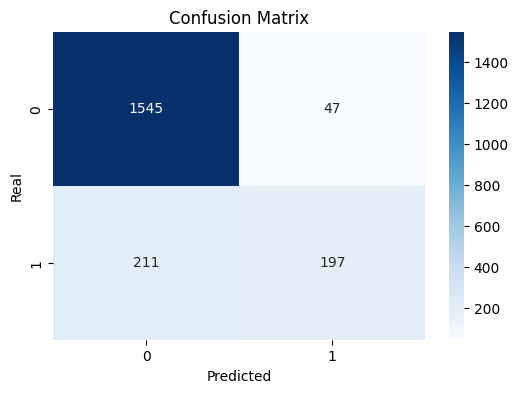

In [7]:
# =========================
# 1. CARGA DE DATOS
# =========================

df = pd.read_csv("../data/processed/churn_processed.csv")

# Eliminamos columnas innecesarias
# df = df.drop(columns=[
#     "RowNumber",
#     "CustomerId",
#     "Surname"
# ])

# =========================
# 2. PREPARACIÓN DE DATOS
# =========================

# One-Hot Encoding para variables categóricas
df_encoded = pd.get_dummies(df, drop_first=True)

# Variables predictoras y target
X = df_encoded.drop("Exited", axis=1)
y = df_encoded["Exited"]

# =========================
# 3. TRAIN / TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ⚠️ No usamos StandardScaler
# porque los modelos basados en árboles no lo necesitan

# =========================
# 4. MODELOS
# =========================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        eval_metric="logloss",
        random_state=42
    )
}

# =========================
# 5. ENTRENAMIENTO + EVALUACIÓN
# =========================

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print(f"\n===== {name} =====")

    print(f"Accuracy:  {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-Score:  {f1:.3f}")

print("\n####################################")

# =========================
# 6. VALIDACIÓN CRUZADA
# =========================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("\n===== Random Forest CV =====")

print(f"F1 medio:   {cv_scores.mean():.3f}")
print(f"Desviación: {cv_scores.std():.3f}")

# =========================
# 7. GRID SEARCH
# =========================

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\n===== Mejor Random Forest =====")

print("Mejores parámetros:")
print(grid.best_params_)

print(f"Mejor F1 CV: {grid.best_score_:.3f}")

# =========================
# 8. EVALUACIÓN FINAL
# =========================

best_rf = grid.best_estimator_

preds = best_rf.predict(X_test)

print("\n===== Random Forest Optimizado =====")

print(f"Accuracy:  {accuracy_score(y_test, preds):.3f}")
print(f"Precision: {precision_score(y_test, preds):.3f}")
print(f"Recall:    {recall_score(y_test, preds):.3f}")
print(f"F1-Score:  {f1_score(y_test, preds):.3f}")

# =========================
# 9. MATRIZ DE CONFUSIÓN
# =========================

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Real")
plt.title("Confusion Matrix")

plt.show()